In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [45]:
# RETO 1: Integración de la Información
from google.colab import drive, files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
path = '/content/drive/MyDrive/Bono'

In [47]:
df_clientes = pd.read_csv('/content/drive/MyDrive/Bono/banco_clientes.csv')

In [48]:
df_transacciones = pd.read_csv('/content/drive/MyDrive/Bono/banco_transacciones.csv')

In [49]:
df = pd.merge(df_clientes, df_transacciones, on='ID_Cliente', how='left')


In [50]:
print("Dimensiones del dataframe (filas, columnas):", df.shape)


Dimensiones del dataframe (filas, columnas): (1000, 7)


In [51]:
# 4. Mostrar las 3 primeras filas
print(df.head(3))

   ID_Cliente       Edad  Ingreso_Mensual Genero  Saldo_Cuenta  \
0           1  46.033413     2.812419e+06      F   2058.469892   
1           2  61.556330     8.323278e+05   Otro   2581.611324   
2           3  48.472947     2.694336e+06      M   6285.609334   

   Cant_Productos  Fuga_Ultimo_Mes  
0             1.0              0.0  
1             1.0              1.0  
2             4.0              0.0  


In [52]:
# Reto 2

mapeo_genero = {
    'm': 'Masculino',
    'M': 'Masculino',


    'f': 'Femenino',
    'F': 'Femenino',


    'otro': 'Otro',

}

df['Genero'] = (
    df['Genero']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(mapeo_genero)
    .fillna('Otro')
)

print(df)

     ID_Cliente       Edad  Ingreso_Mensual     Genero  Saldo_Cuenta  \
0             1  46.033413     2.812419e+06   Femenino   2058.469892   
1             2  61.556330     8.323278e+05       Otro   2581.611324   
2             3  48.472947     2.694336e+06  Masculino   6285.609334   
3             4  37.087825     5.412067e+06   Femenino  16395.151188   
4             5        NaN     4.598928e+06  Masculino  15631.855902   
..          ...        ...              ...        ...           ...   
995         996  42.393088     4.158149e+06  Masculino    201.524125   
996         997  45.676459     1.194115e+06   Femenino   8995.466974   
997         998  32.253135     4.210203e+06  Masculino   7618.716062   
998         999  20.066999     1.285349e+06   Femenino   1312.705771   
999        1000  46.039025     5.075330e+06       Otro   4298.880677   

     Cant_Productos  Fuga_Ultimo_Mes  
0               1.0              0.0  
1               1.0              1.0  
2               4.

In [53]:
# 2. Imputación de Valores Nulos
# Justificación Edad e Ingresos: Usamos la mediana porque es una medida robusta que no se ve afectada por valores extremos u outliers.
df['Edad'] = df['Edad'].fillna(df['Edad'].median())
df['Ingreso_Mensual'] = df['Ingreso_Mensual'].fillna(df['Ingreso_Mensual'].median())

# Justificación Transacciones: Si un cliente tiene nulos aquí, asumimos que no tiene productos financieros activos con el banco.
df['Saldo_Cuenta'] = df['Saldo_Cuenta'].fillna(0)
df['Cant_Productos'] = df['Cant_Productos'].fillna(0)
df['Fuga_Ultimo_Mes'] = df['Fuga_Ultimo_Mes'].fillna(0)


In [54]:
# 3. Tratamiento de Outliers (Edad = 150)
# Justificación: Una edad de 150 años es claramente un error de digitación.
# Lo reemplazamos por la mediana de la edad del resto de clientes para no alterar la distribución general perdiendo la fila.
mediana_edad = df.loc[df['Edad'] < 100, 'Edad'].median()
df.loc[df['Edad'] >= 150, 'Edad'] = mediana_edad

In [55]:
# RETO 3: Transformación (Data Manipulation)
# 1. Crear columna Ingreso_Anual
df['Ingreso_Anual'] = df['Ingreso_Mensual'] * 12

In [56]:
# 2. Tabla agrupada para la Junta Directiva
resumen_junta = df.groupby(['Genero', 'Fuga_Ultimo_Mes'])['Saldo_Cuenta'].mean().reset_index()
print("\nResumen para la Junta (Saldo Promedio):")
print(resumen_junta)


Resumen para la Junta (Saldo Promedio):
      Genero  Fuga_Ultimo_Mes  Saldo_Cuenta
0   Femenino              0.0   7522.952769
1   Femenino              1.0   1893.418247
2  Masculino              0.0   6512.500996
3  Masculino              1.0   1191.770698
4       Otro              0.0   7121.202594
5       Otro              1.0   1457.266614


/tmp/ipykernel_374/1058180546.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Cant_Productos', y='Fuga_Ultimo_Mes', data=df, ci=None)


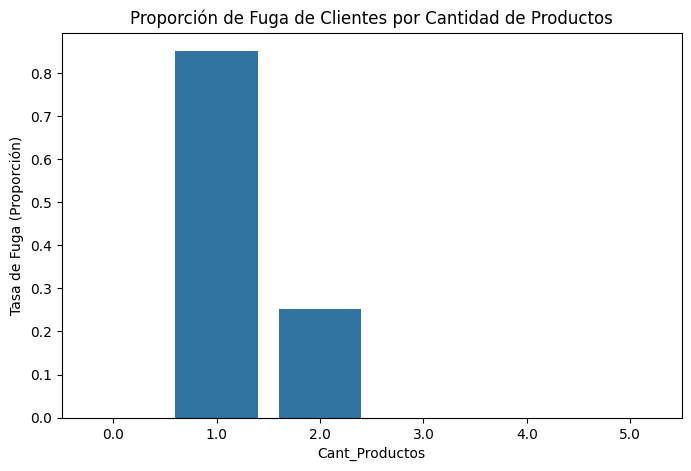

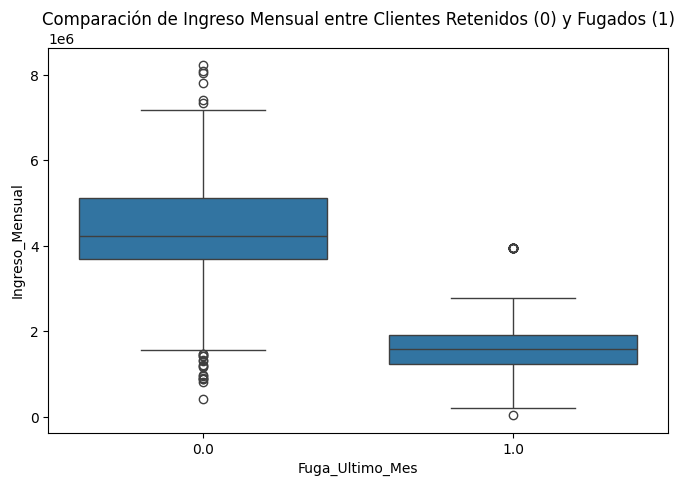

In [57]:
# RETO 4: Análisis Exploratorio - EDA
# 1. Diagrama de barras: Proporción de fuga según Cant_Productos
plt.figure(figsize=(8, 5))
sns.barplot(x='Cant_Productos', y='Fuga_Ultimo_Mes', data=df, ci=None)
plt.title('Proporción de Fuga de Clientes por Cantidad de Productos')
plt.ylabel('Tasa de Fuga (Proporción)')
plt.show()

# 2. Boxplot: Ingreso_Mensual vs Fuga
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fuga_Ultimo_Mes', y='Ingreso_Mensual', data=df)
plt.title('Comparación de Ingreso Mensual entre Clientes Retenidos (0) y Fugados (1)')
plt.show()

Análisis para el Reto 4: Análisis Exploratorio (EDA)
Pitch Económico para la Junta Directiva

Estimados miembros de la Junta: El análisis cruzado de nuestra demografía y transaccionalidad revela un problema estructural de anclaje financiero. Al evaluar la proporción de fuga, no observamos un simple patrón aleatorio, sino un comportamiento racional del consumidor. Los clientes con un solo producto activo presentan la tasa de abandono más crítica. En términos económicos, esto significa que sus costos de cambio (switching costs) son nulos; sin vínculos como créditos, inversiones o cuentas de nómina, la barrera de salida es inexistente frente a las ofertas de la competencia. Simultáneamente, la distribución de ingresos nos indica que la sensibilidad a costos transaccionales (como cuotas de manejo) está expulsando a un nicho específico. El banco no está logrando rentabilizar ni retener al usuario base.

Medidas Recomendadas a la Junta Directiva
Para mitigar la destrucción de valor presente neto ocasionada por la fuga, se proponen las siguientes directrices estratégicas:
1. Campaña Agresiva de Venta Cruzada (Cross-Selling): La prioridad transaccional debe ser llevar a los clientes de 1 producto a tener 2 o más. Se recomienda aprobar de manera automática productos de fricción baja (ej. tarjetas de crédito con cuota de manejo exonerada por un año o líneas de microcrédito rotativo) al segmento con buen saldo promedio pero baja vinculación.
2. Estructuración de Beneficios por Fidelización: Diseñar un modelo tarifario escalonado donde se eliminen los cobros por retiros o transferencias a cambio de domiciliar pagos o mantener un saldo promedio mínimo. Esto eleva los costos de salida del cliente, asegurando su permanencia a largo plazo.

In [58]:
# RETO 5: Preparación para Machine Learning
# 1. One-Hot Encoding a la columna Genero
# Usamos drop_first=True para eliminar la primera columna dummy y así evitar problemas de multicolinealidad exacta.
df = pd.get_dummies(df, columns=['Genero'], drop_first=True)

# 2. Escalar columnas numéricas (StandardScaler)
# Esto asegura que ingresos y saldos estén en magnitudes comparables para los algoritmos.
scaler = StandardScaler()
df[['Ingreso_Mensual', 'Saldo_Cuenta']] = scaler.fit_transform(df[['Ingreso_Mensual', 'Saldo_Cuenta']])

print("\nTransformaciones finales aplicadas con éxito. Base lista para ML.")


Transformaciones finales aplicadas con éxito. Base lista para ML.


In [59]:
print(df)

     ID_Cliente       Edad  Ingreso_Mensual  Saldo_Cuenta  Cant_Productos  \
0             1  46.033413        -0.597392     -0.542484             1.0   
1             2  61.556330        -1.874296     -0.467535             1.0   
2             3  48.472947        -0.673541      0.063122             4.0   
3             4  37.087825         1.079046      1.511478             4.0   
4             5  39.298402         0.554676      1.402124             3.0   
..          ...        ...              ...           ...             ...   
995         996  42.393088         0.270431     -0.808521             3.0   
996         997  45.676459        -1.640989      0.451353             2.0   
997         998  32.253135         0.303999      0.254111             3.0   
998         999  20.066999        -1.582156     -0.649327             1.0   
999        1000  46.039025         0.861894     -0.221509             5.0   

     Fuga_Ultimo_Mes  Ingreso_Anual  Genero_Masculino  Genero_Otro  
0     